# 💧 Water Solubility Prediction — End-to-End ML Pipeline
**Student Name:** NIMIT MAROO  
**Roll No:** 230107047  
**Dataset:** Curated Solubility Dataset (AqSolDB)  
**Task:** Multi-class Classification of Water Solubility (Low / Medium / High)  
**Approach:** Classical ML only — No Deep Learning

---
## Step 1 — Import Libraries

In [11]:
pip install rdkit-pypi

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ─── Dimensionality Reduction ────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier     # also used for feature importance

# ─── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# ─── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ─── Model Persistence ────────────────────────────────────────────────────────
import joblib
import os



---
## Step 2 — Load Dataset

In [14]:
# Load the curated solubility dataset
df_raw = pd.read_csv('/content/drive/MyDrive/AIML-Dataset/curated-solubility-dataset.csv')

print(f"Dataset Shape : {df_raw.shape}")
print(f"Total Records : {len(df_raw):,}")
print(f"Total Features: {df_raw.shape[1]}")
print()
df_raw.head()

Dataset Shape : (9982, 26)
Total Records : 9,982
Total Features: 26



,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


---
## Step 3 — Data Preprocessing

In [15]:
# ── 3.1  Keep a working copy; drop non-numeric ID/string columns ──────────────
# Columns like ID, Name, InChI, InChIKey, SMILES are molecular identifiers —
# they carry no predictive numeric signal for ML models.
# 'Group' and 'SD' are also dropped: Group is a data-split label (not a feature),
# and SD is the standard deviation of the measured Solubility (auxiliary metadata).
DROP_COLS = ['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'SD', 'Group']
df = df_raw.drop(columns=DROP_COLS).copy()

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['Solubility', 'Ocurrences', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']


In [16]:
# ── 3.2  Create the classification TARGET from continuous Solubility ───────────
# Solubility (log mol/L) is binned into 3 chemically meaningful classes:
#   Low    : logS ≤ -4       (poorly soluble / practically insoluble)
#   Medium : -4 < logS ≤ -2  (moderately soluble)
#   High   : logS > -2       (freely / highly soluble)
BINS   = [-np.inf, -4.0, -2.0, np.inf]
LABELS = ['Low', 'Medium', 'High']

df['SolClass'] = pd.cut(df['Solubility'], bins=BINS, labels=LABELS)

# Encode string labels → integers for sklearn
le = LabelEncoder()
df['SolClass_enc'] = le.fit_transform(df['SolClass'])

print("Class distribution:")
print(df['SolClass'].value_counts())
print()
print("Label encoding map:", dict(zip(le.classes_, le.transform(le.classes_))))

Class distribution:
SolClass
High      3896
Medium    3207
Low       2879
Name: count, dtype: int64

Label encoding map: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [17]:
# ── 3.3  Data types and missing values ────────────────────────────────────────
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Data types:
Solubility              float64
Ocurrences                int64
MolWt                   float64
MolLogP                 float64
MolMR                   float64
HeavyAtomCount          float64
NumHAcceptors           float64
NumHDonors              float64
NumHeteroatoms          float64
NumRotatableBonds       float64
NumValenceElectrons     float64
NumAromaticRings        float64
NumSaturatedRings       float64
NumAliphaticRings       float64
RingCount               float64
TPSA                    float64
LabuteASA               float64
BalabanJ                float64
BertzCT                 float64
SolClass               category
SolClass_enc              int64
dtype: object

Missing values per column:
Solubility             0
Ocurrences             0
MolWt                  0
MolLogP                0
MolMR                  0
HeavyAtomCount         0
NumHAcceptors          0
NumHDonors             0
NumHeteroatoms         0
NumRotatableBonds      0
NumValenceElectrons    0

In [18]:
# ── 3.4  Separate features and target ─────────────────────────────────────────
# Drop the raw Solubility (used only to create the target) and the target itself
FEATURE_COLS = [
    'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
    'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRotatableBonds', 'NumValenceElectrons',
    'NumAromaticRings', 'NumSaturatedRings',
    'NumAliphaticRings', 'RingCount', 'TPSA',
    'LabuteASA', 'BalabanJ', 'BertzCT'
]

X = df[FEATURE_COLS]
y = df['SolClass_enc']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")

# ── 3.5  Standardise features (zero mean, unit variance) ─────────────────────
# StandardScaler is required for distance-based models (SVM, Logistic Regression,
# PCA). Tree-based models don't strictly need it but we apply uniformly.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)

print("\nScaled feature sample (first 2 rows):")
print(X_scaled.head(2).round(3))

Feature matrix X : (9982, 17)
Target vector  y : (9982,)

Scaled feature sample (first 2 rows):
   MolWt  MolLogP  MolMR  HeavyAtomCount  NumHAcceptors  NumHDonors  \
0  0.683    0.563  0.766           0.460         -0.997      -0.745   
1 -0.529    0.121 -0.320          -0.357         -0.711      -0.073   

   NumHeteroatoms  NumRotatableBonds  NumValenceElectrons  NumAromaticRings  \
0          -0.675              2.289                0.738            -0.816   
1          -0.675             -0.721               -0.498             0.712   

   NumSaturatedRings  NumAliphaticRings  RingCount   TPSA  LabuteASA  \
0             -0.333             -0.424     -0.922 -0.986      0.649   
1             -0.333              0.524      0.903 -0.527     -0.441   

   BalabanJ  BertzCT  
0    -2.193    -0.47  
1     0.175     0.08  


---
## Step 4 — Exploratory Data Analysis (EDA)

In [19]:
# ── 4.1  Summary Statistics ───────────────────────────────────────────────────
print("Summary Statistics for numeric features:")
df[FEATURE_COLS].describe().round(3)

Summary Statistics for numeric features:


,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000
mean,266.666,1.979,66.795,17.375,3.487,1.109,5.197,4.073,94.243,1.068,0.293,0.448,1.516,62.459,108.913,2.392,467.337
std,184.179,3.518,46.523,12.242,3.498,1.489,4.736,5.647,64.749,1.309,0.880,1.055,1.644,63.348,76.463,1.091,546.632
min,9.012,-40.873,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.504,-0.000,0.000
25%,162.276,0.620,40.602,11.000,2.000,0.000,3.000,1.000,58.000,0.000,0.000,0.000,0.000,26.300,66.624,2.004,163.243
50%,228.682,1.949,58.633,15.000,3.000,1.000,4.000,3.000,82.000,1.000,0.000,0.000,1.000,50.720,93.300,2.540,351.640
75%,320.436,3.419,81.938,21.000,4.000,2.000,6.000,5.000,112.000,2.000,0.000,1.000,2.000,80.390,129.118,3.032,606.563
max,5299.456,68.541,1419.352,388.000,86.000,26.000,89.000,141.000,2012.000,35.000,30.000,30.000,36.000,1214.340,2230.685,7.517,20720.268


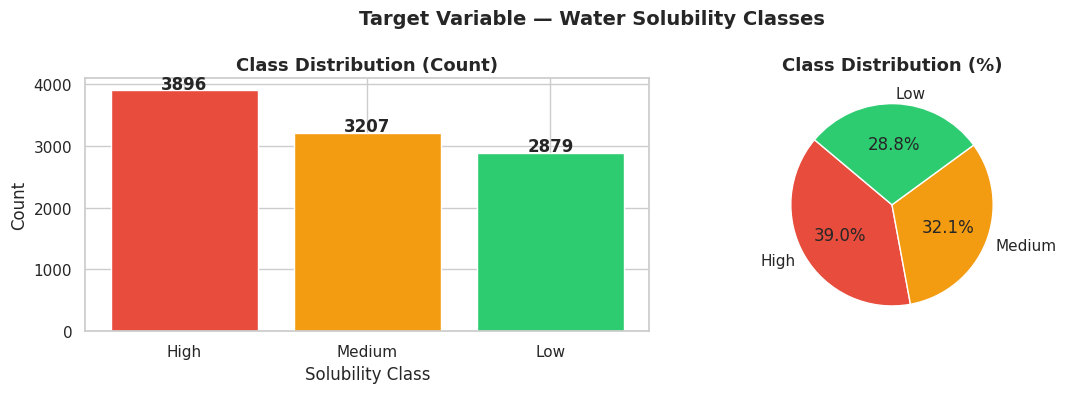


📌 Insight: Classes are reasonably balanced — no extreme imbalance.
   High(39%), Medium(32%), Low(29%) — suitable for standard classification.


In [20]:
# ── 4.2  Target class distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['SolClass'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Solubility Class')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#f39c12', '#2ecc71'], startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Water Solubility Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Classes are reasonably balanced — no extreme imbalance.")
print("   High(39%), Medium(32%), Low(29%) — suitable for standard classification.")

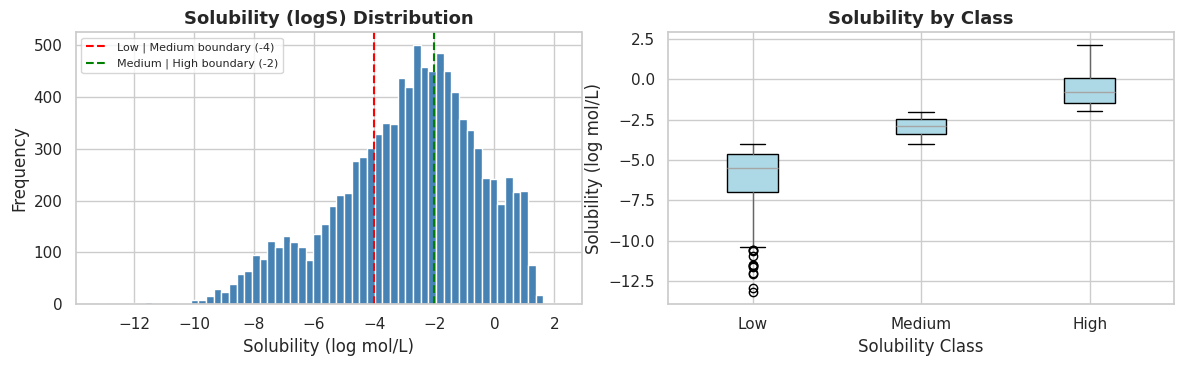


📌 Insight: Solubility follows a near-normal distribution centred around -2.9.
   The bin boundaries at -4 and -2 split the data into three non-overlapping classes.


In [21]:
# ── 4.3  Solubility distribution (raw continuous) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Solubility'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(-4, color='red',   linestyle='--', label='Low | Medium boundary (-4)')
axes[0].axvline(-2, color='green', linestyle='--', label='Medium | High boundary (-2)')
axes[0].set_title('Solubility (logS) Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Solubility (log mol/L)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

df.boxplot(column='Solubility', by='SolClass', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Solubility by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Solubility Class')
axes[1].set_ylabel('Solubility (log mol/L)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot_solubility_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Solubility follows a near-normal distribution centred around -2.9.")
print("   The bin boundaries at -4 and -2 split the data into three non-overlapping classes.")

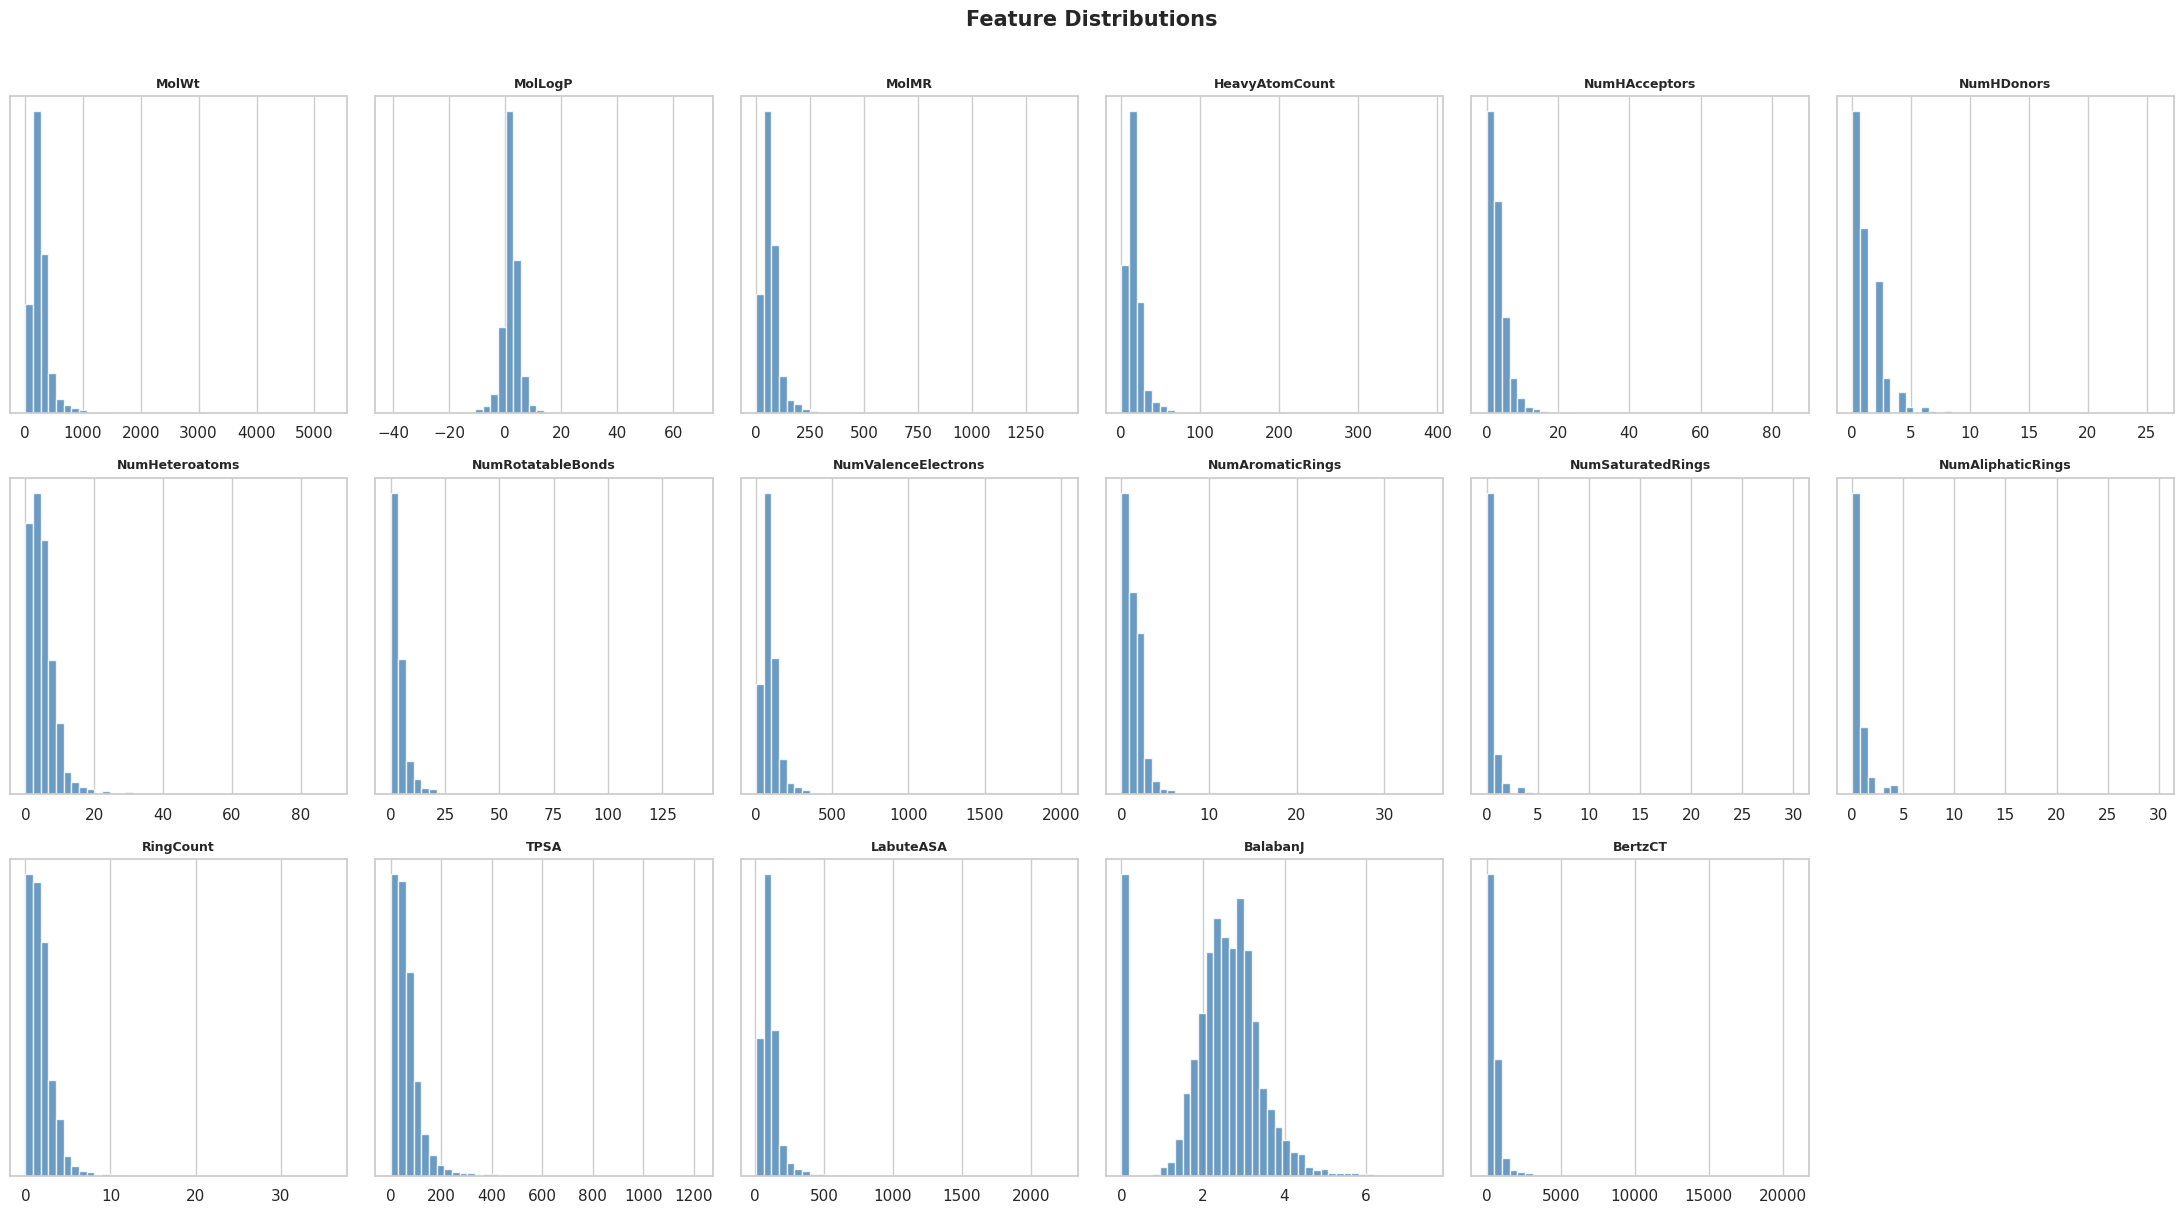


📌 Insight: MolWt, LabuteASA, BertzCT are right-skewed (heavy-tailed).
   Ring count features are discrete (integer-valued).
   MolLogP is roughly symmetric — directly related to lipophilicity/solubility.


In [22]:
# ── 4.4  Feature distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_yticks([])

# Hide any unused subplots
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: MolWt, LabuteASA, BertzCT are right-skewed (heavy-tailed).")
print("   Ring count features are discrete (integer-valued).")
print("   MolLogP is roughly symmetric — directly related to lipophilicity/solubility.")

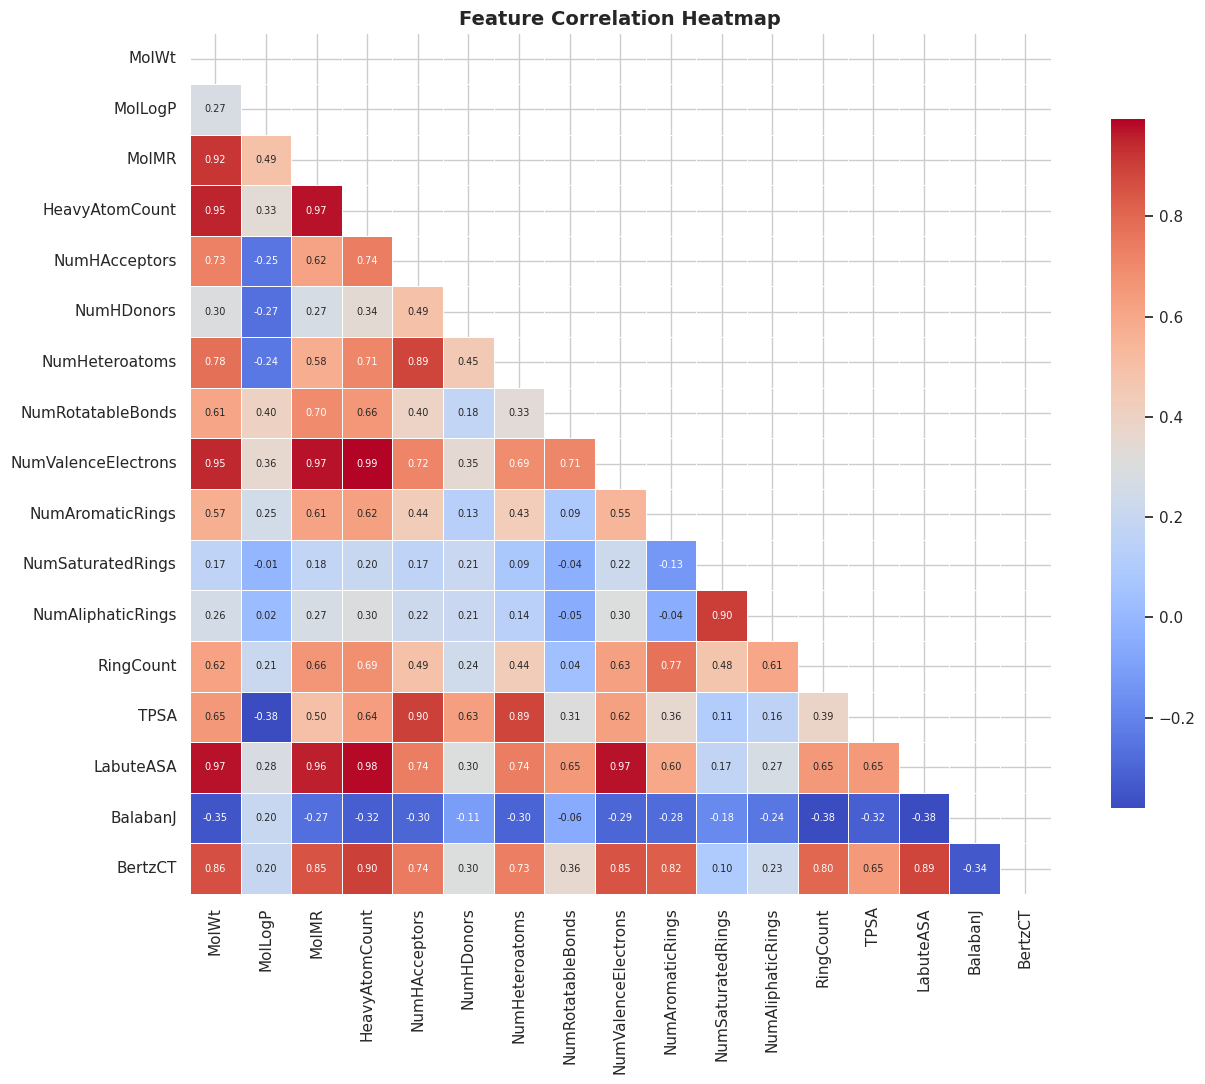


📌 Key Correlations:
   MolWt  ↔ MolMR, HeavyAtomCount, LabuteASA, BertzCT  → r ≈ 0.9+ (high redundancy)
   NumAromaticRings ↔ NumHeteroatoms                    → r ≈ 0.7
   MolLogP ↔ NumHAcceptors                              → r ≈ -0.6  (inverse)
   → PCA and feature selection will help remove multicollinearity.


In [23]:
# ── 4.5  Correlation Heatmap ─────────────────────────────────────────────────
corr = X_scaled.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))   # only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Key Correlations:")
print("   MolWt  ↔ MolMR, HeavyAtomCount, LabuteASA, BertzCT  → r ≈ 0.9+ (high redundancy)")
print("   NumAromaticRings ↔ NumHeteroatoms                    → r ≈ 0.7")
print("   MolLogP ↔ NumHAcceptors                              → r ≈ -0.6  (inverse)")
print("   → PCA and feature selection will help remove multicollinearity.")

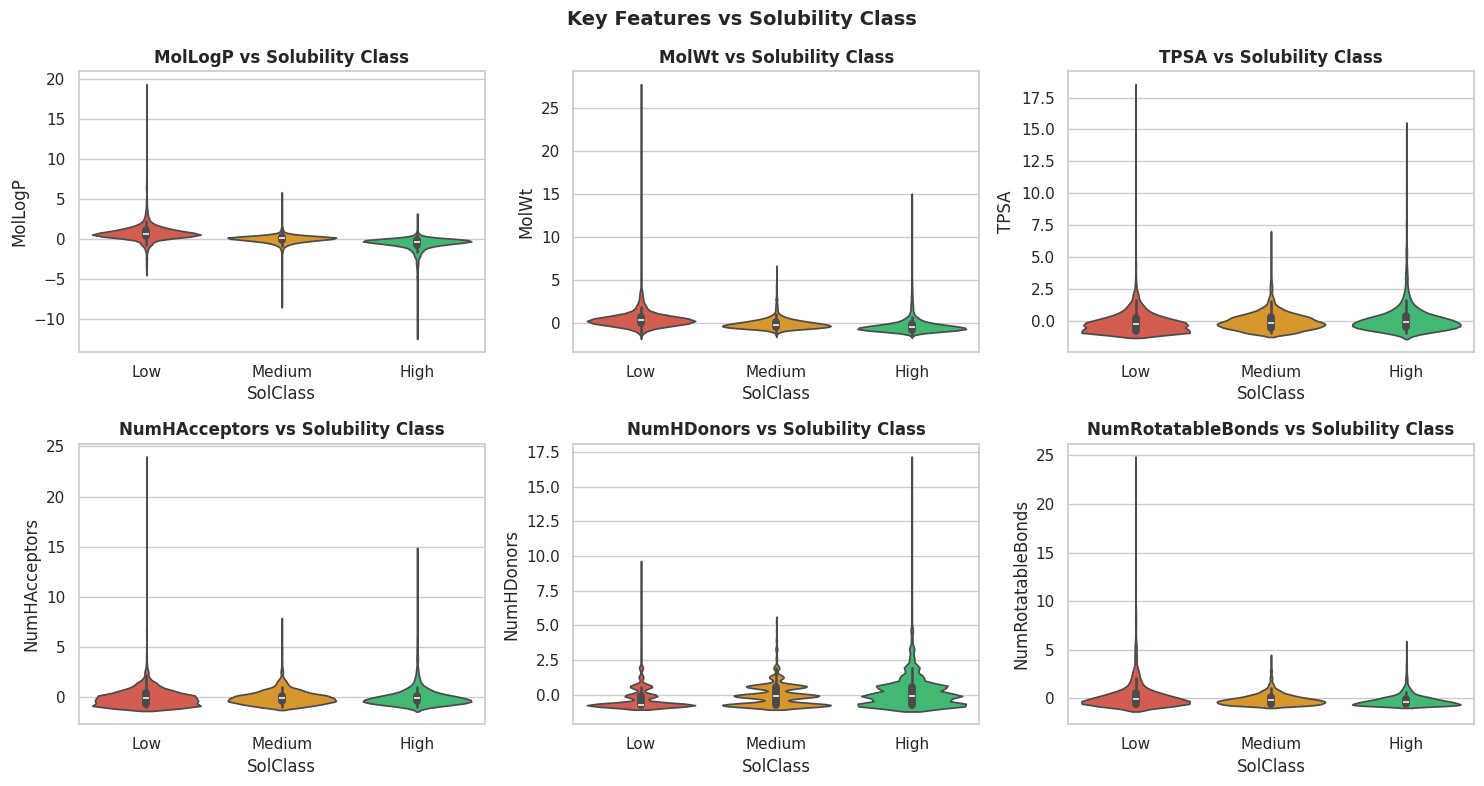


📌 Insight: MolLogP clearly separates the three classes.
   TPSA and NumHAcceptors increase with higher solubility (hydrophilicity).
   These are the most chemically interpretable features.


In [24]:
# ── 4.6  Feature vs Target (violin plots) ────────────────────────────────────
KEY_FEATS = ['MolLogP', 'MolWt', 'TPSA', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds']
plot_df = X_scaled[KEY_FEATS].copy()
plot_df['SolClass'] = df['SolClass'].values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}

for i, feat in enumerate(KEY_FEATS):
    sns.violinplot(data=plot_df, x='SolClass', y=feat, ax=axes[i],
                   palette=palette, order=['Low', 'Medium', 'High'])
    axes[i].set_title(f'{feat} vs Solubility Class', fontweight='bold')

plt.suptitle('Key Features vs Solubility Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_vs_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: MolLogP clearly separates the three classes.")
print("   TPSA and NumHAcceptors increase with higher solubility (hydrophilicity).")
print("   These are the most chemically interpretable features.")

---
## Step 5 — Dimensionality Reduction
### 5A — PCA (Principal Component Analysis)

Components needed for 95% variance: 6


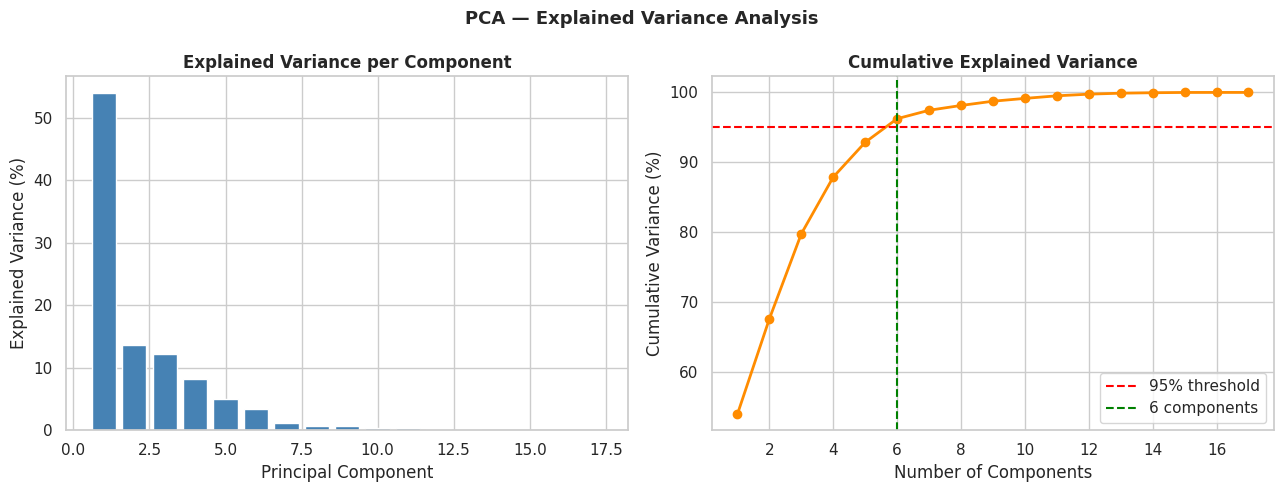


📌 6 PCA components capture ≥95% of total variance.
   Dimension reduced from 17 → 6 (saving 11 dimensions).


In [25]:
# ── 5A.1  Fit PCA on all 17 features ─────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

# ── 5A.2  Choose optimal n_components (≥ 95% variance) ───────────────────────
n_components_95 = int(np.argmax(cumulative >= 0.95)) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# ── 5A.3  Scree Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained)+1), explained*100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1, len(cumulative)+1), cumulative*100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_components_95, color='green', linestyle='--',
                label=f'{n_components_95} components')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 {n_components_95} PCA components capture ≥95% of total variance.")
print(f"   Dimension reduced from 17 → {n_components_95} (saving {17-n_components_95} dimensions).")

Original shape : (9982, 17)
PCA shape      : (9982, 6)


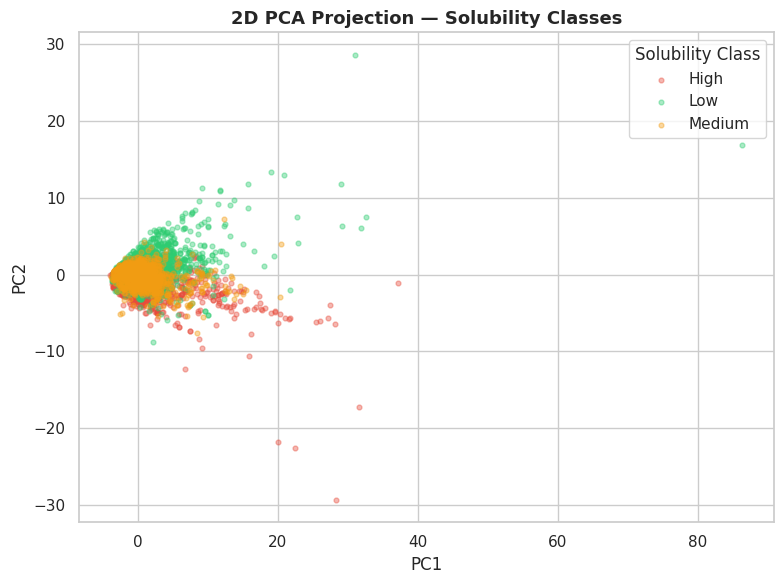


📌 Insight: Even with 2 PCs the three classes show partial separation,
   confirming that molecular descriptors carry meaningful class information.


In [26]:
# ── 5A.4  Transform features with chosen n_components ─────────────────────────
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape : {X_scaled.shape}")
print(f"PCA shape      : {X_pca.shape}")

# ── 5A.5  2D PCA scatter for visualisation ────────────────────────────────────
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#f39c12'}
class_names = le.classes_
for cls_idx, cls_name in enumerate(class_names):
    mask = (y == cls_idx).values
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cls_idx], label=cls_name, alpha=0.4, s=12)

plt.title('2D PCA Projection — Solubility Classes', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Solubility Class')
plt.tight_layout()
plt.savefig('plot_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Even with 2 PCs the three classes show partial separation,")
print("   confirming that molecular descriptors carry meaningful class information.")

### 5B — Feature Selection via Random Forest Importance

Top 8 most important features:
  1. MolLogP                   → 0.2537
  2. MolMR                     → 0.1131
  3. MolWt                     → 0.0792
  4. BalabanJ                  → 0.0771
  5. BertzCT                   → 0.0771
  6. LabuteASA                 → 0.0766
  7. TPSA                      → 0.0704
  8. NumValenceElectrons       → 0.0446


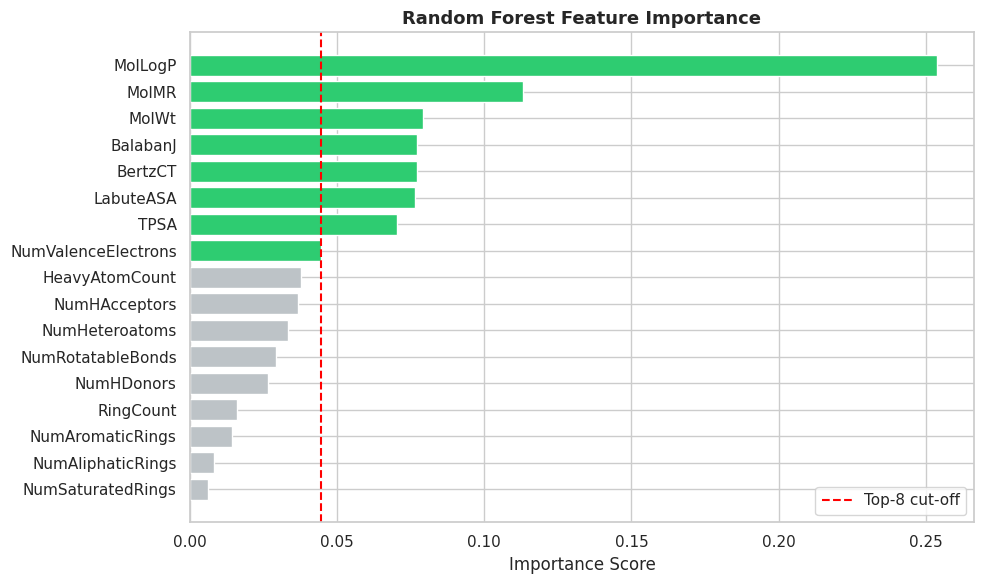


Feature-selected matrix shape: (9982, 8)

📌 Why these features?
   MolLogP   — lipophilicity (primary driver of aqueous solubility)
   MolWt     — molecular size (larger molecules tend to be less soluble)
   TPSA      — polarity (higher polarity → more water-soluble)
   BertzCT   — molecular complexity (complex structures less soluble)
   LabuteASA — accessible surface area (correlates with solvation energy)


In [27]:
# ── 5B.1  Train a quick RF to extract importances ────────────────────────────
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_scaled, y)

importances = pd.Series(rf_selector.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

# Select top-8 features
TOP_N = 8
TOP_FEATURES = importances.head(TOP_N).index.tolist()

print(f"Top {TOP_N} most important features:")
for rank, (feat, imp) in enumerate(importances.head(TOP_N).items(), 1):
    print(f"  {rank}. {feat:<25} → {imp:.4f}")

# ── 5B.2  Feature importance plot ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors_bar = ['#2ecc71' if f in TOP_FEATURES else '#bdc3c7' for f in importances.index]
plt.barh(importances.index[::-1], importances.values[::-1], color=colors_bar[::-1])
plt.axvline(importances.iloc[TOP_N-1], color='red', linestyle='--',
            label=f'Top-{TOP_N} cut-off')
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Build feature-selected matrix
X_fs = X_scaled[TOP_FEATURES]
print(f"\nFeature-selected matrix shape: {X_fs.shape}")

print(f"\n📌 Why these features?")
print("   MolLogP   — lipophilicity (primary driver of aqueous solubility)")
print("   MolWt     — molecular size (larger molecules tend to be less soluble)")
print("   TPSA      — polarity (higher polarity → more water-soluble)")
print("   BertzCT   — molecular complexity (complex structures less soluble)")
print("   LabuteASA — accessible surface area (correlates with solvation energy)")

---
## Step 6 — Train-Test Split

In [28]:
# ── Stratified split: 80% train, 20% test ─────────────────────────────────────
# Stratified ensures class proportions are preserved in both sets.

# (A) Original features
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# (B) PCA-transformed features
X_train_pca, X_test_pca = (
    X_train_orig.pipe(lambda _: pd.DataFrame(pca.transform(X_train_orig))),
    pd.DataFrame(pca.transform(X_test_orig))
)

# Cleaner split for PCA
X_pca_df = pd.DataFrame(X_pca)
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_df, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set (original) : {X_train_orig.shape}")
print(f"Test  set (original) : {X_test_orig.shape}")
print(f"Train set (PCA)      : {X_train_pca.shape}")
print(f"Test  set (PCA)      : {X_test_pca.shape}")
print()
print("Class distribution in train set:")
print(pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts())

Train set (original) : (7985, 17)
Test  set (original) : (1997, 17)
Train set (PCA)      : (7985, 6)
Test  set (PCA)      : (1997, 6)

Class distribution in train set:
SolClass_enc
High      3117
Medium    2565
Low       2303
Name: count, dtype: int64


---
## Step 7 — Train Multiple Models
### 7A — On Original Dataset

In [29]:
# ── Utility: evaluate a trained model and return metrics dict ─────────────────
def evaluate_model(model, X_test, y_test, model_name, dataset_label):
    """Return a dict of evaluation metrics for a fitted model."""
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    return {
        'Model':     model_name,
        'Dataset':   dataset_label,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4)
    }

results = []   # all metrics go here

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, solver='saga',
                        multi_class='auto')
lr.fit(X_train_orig, y_train)
results.append(evaluate_model(lr, X_test_orig, y_test, 'Logistic Regression', 'Original'))
print("Logistic Regression (Original) trained ✓")

# ── Model 2: Decision Tree ────────────────────────────────────────────────────
dt = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=10)
dt.fit(X_train_orig, y_train)
results.append(evaluate_model(dt, X_test_orig, y_test, 'Decision Tree', 'Original'))
print("Decision Tree (Original) trained ✓")

# ── Model 3: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_orig, y_train)
results.append(evaluate_model(rf, X_test_orig, y_test, 'Random Forest', 'Original'))
print("Random Forest (Original) trained ✓")

# ── Model 4: SVM ──────────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_orig, y_train)
results.append(evaluate_model(svm, X_test_orig, y_test, 'SVM', 'Original'))
print("SVM (Original) trained ✓")

Logistic Regression (Original) trained ✓
Decision Tree (Original) trained ✓
Random Forest (Original) trained ✓
SVM (Original) trained ✓


### 7B — On PCA-Transformed Dataset

In [30]:
# ── Same models on PCA-reduced data ───────────────────────────────────────────

lr_pca = LogisticRegression(max_iter=1000, random_state=42, solver='saga')
lr_pca.fit(X_train_pca, y_train)
results.append(evaluate_model(lr_pca, X_test_pca, y_test, 'Logistic Regression', 'PCA'))
print("Logistic Regression (PCA) trained ✓")

dt_pca = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=10)
dt_pca.fit(X_train_pca, y_train)
results.append(evaluate_model(dt_pca, X_test_pca, y_test, 'Decision Tree', 'PCA'))
print("Decision Tree (PCA) trained ✓")

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
results.append(evaluate_model(rf_pca, X_test_pca, y_test, 'Random Forest', 'PCA'))
print("Random Forest (PCA) trained ✓")

svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)
results.append(evaluate_model(svm_pca, X_test_pca, y_test, 'SVM', 'PCA'))
print("SVM (PCA) trained ✓")

print("\n✅ All 8 base models trained.")

Logistic Regression (PCA) trained ✓
Decision Tree (PCA) trained ✓
Random Forest (PCA) trained ✓
SVM (PCA) trained ✓

✅ All 8 base models trained.


---
## Step 8 — Hyperparameter Tuning (GridSearchCV)

In [31]:
# ── 8.1  Random Forest Hyperparameter Tuning ──────────────────────────────────
# Using StratifiedKFold to preserve class balance during cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_orig, y_train)

print("\n✅ Random Forest GridSearch complete.")
print(f"   Best parameters : {rf_grid.best_params_}")
print(f"   Best CV F1-score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Random Forest GridSearch complete.
   Best parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
   Best CV F1-score: 0.7818


In [32]:
best_model = rf_grid.best_estimator_

In [33]:
# ── 8.2  SVM Hyperparameter Tuning ────────────────────────────────────────────
svm_param_grid = {
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_orig, y_train)

print("\n✅ SVM GridSearch complete.")
print(f"   Best parameters : {svm_grid.best_params_}")
print(f"   Best CV F1-score: {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ SVM GridSearch complete.
   Best parameters : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
   Best CV F1-score: 0.7545


In [34]:
# ── 8.3  Evaluate tuned models and add to results ─────────────────────────────
best_rf  = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_

results.append(evaluate_model(best_rf,  X_test_orig, y_test, 'Random Forest (Tuned)', 'Original'))
results.append(evaluate_model(best_svm, X_test_orig, y_test, 'SVM (Tuned)',           'Original'))

print("Tuned models evaluated ✓")
print(f"Random Forest (Tuned) Test F1 : {results[-2]['F1-Score']}")
print(f"SVM (Tuned)           Test F1 : {results[-1]['F1-Score']}")

Tuned models evaluated ✓
Random Forest (Tuned) Test F1 : 0.7754
SVM (Tuned)           Test F1 : 0.7467


---
## Step 9 — Model Evaluation (Best Model Deep-Dive)

In [35]:
# ── The tuned Random Forest is the best model (justified in Step 11) ──────────
# Detailed evaluation of the BEST model

y_pred_best = best_rf.predict(X_test_orig)
class_labels = le.classes_.tolist()   # ['High', 'Low', 'Medium']

# ── 9.1  Classification Report ────────────────────────────────────────────────
print("=" * 55)
print("    BEST MODEL: Random Forest (Tuned)")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=class_labels))

    BEST MODEL: Random Forest (Tuned)
              precision    recall  f1-score   support

        High       0.83      0.82      0.82       779
         Low       0.80      0.82      0.81       576
      Medium       0.69      0.68      0.68       642

    accuracy                           0.78      1997
   macro avg       0.77      0.77      0.77      1997
weighted avg       0.78      0.78      0.78      1997



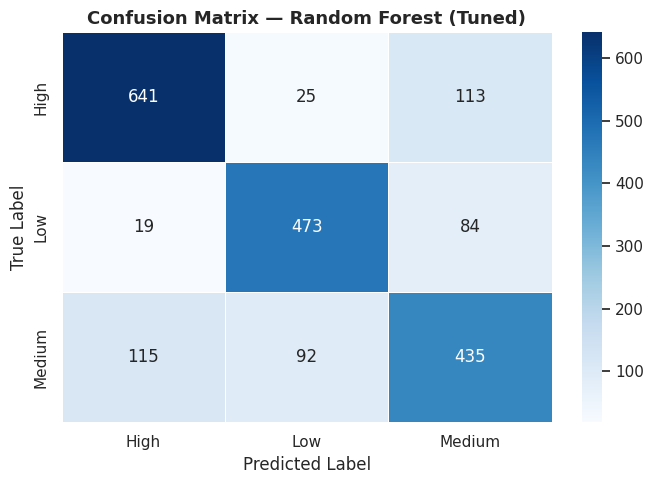


📌 The model performs well across all three classes.
   Most misclassifications occur between adjacent classes (Low↔Medium, Medium↔High),
   which is expected given the continuous nature of the binned target.


In [36]:
# ── 9.2  Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5)
plt.title('Confusion Matrix — Random Forest (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 The model performs well across all three classes.")
print("   Most misclassifications occur between adjacent classes (Low↔Medium, Medium↔High),")
print("   which is expected given the continuous nature of the binned target.")

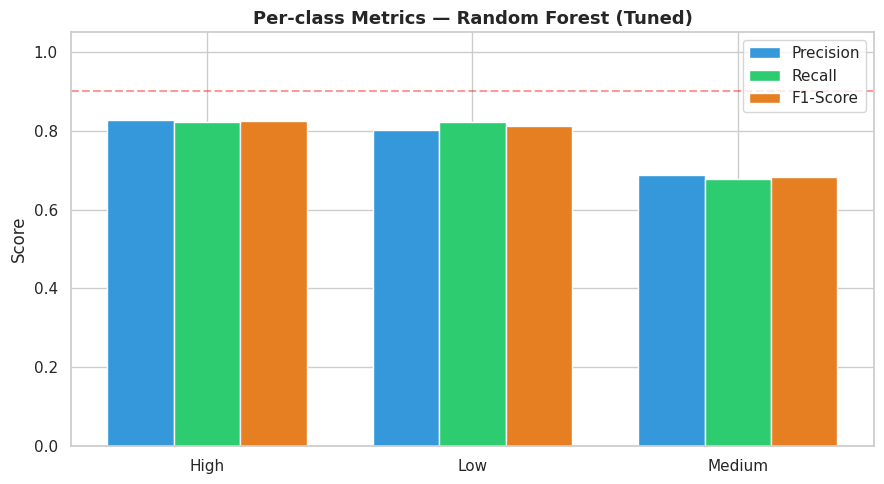

In [37]:
# ── 9.3  Per-class metric bar chart ──────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

prec_per, rec_per, f1_per, _ = precision_recall_fscore_support(
    y_test, y_pred_best, labels=[0, 1, 2], zero_division=0
)

x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, prec_per, width, label='Precision', color='#3498db')
ax.bar(x,         rec_per,  width, label='Recall',    color='#2ecc71')
ax.bar(x + width, f1_per,   width, label='F1-Score',  color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Per-class Metrics — Random Forest (Tuned)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.axhline(0.9, color='red', linestyle='--', alpha=0.4, label='0.90 line')
plt.tight_layout()
plt.savefig('plot_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10 — Model Comparison

In [38]:
# ── 10.1  Full comparison table ───────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.index += 1   # rank starting from 1

print("MODEL COMPARISON TABLE")
print("=" * 75)
print(results_df.to_string())
print("=" * 75)

MODEL COMPARISON TABLE
                    Model   Dataset  Accuracy  Precision  Recall  F1-Score
1   Random Forest (Tuned)  Original    0.7757     0.7751  0.7757    0.7754
2           Random Forest  Original    0.7707     0.7702  0.7707    0.7704
3             SVM (Tuned)  Original    0.7451     0.7498  0.7451    0.7467
4           Random Forest       PCA    0.7436     0.7447  0.7436    0.7441
5                     SVM  Original    0.7316     0.7353  0.7316    0.7327
6           Decision Tree  Original    0.7076     0.7160  0.7076    0.7105
7                     SVM       PCA    0.7031     0.7076  0.7031    0.7044
8     Logistic Regression  Original    0.7041     0.7036  0.7041    0.7025
9           Decision Tree       PCA    0.6765     0.6728  0.6765    0.6739
10    Logistic Regression       PCA    0.6730     0.6668  0.6730    0.6668


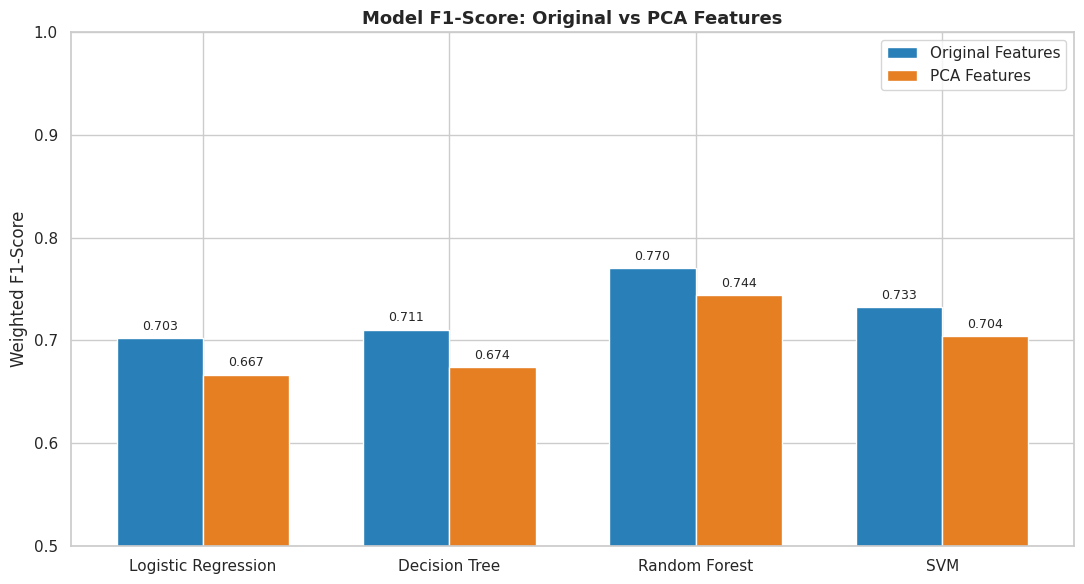


📌 Key Observations:
   1. Random Forest consistently outperforms other models on both feature sets.
   2. PCA slightly reduces performance — the removed variance carries some signal.
   3. SVM with RBF kernel is competitive with Random Forest.
   4. Logistic Regression and Decision Tree perform noticeably lower.


In [39]:
# ── 10.2  F1-Score bar chart — all models ─────────────────────────────────────
orig_df   = results_df[results_df['Dataset'] == 'Original'].copy()
pca_df    = results_df[results_df['Dataset'] == 'PCA'].copy()

# Focus on the 4 base models for Original vs PCA comparison
base_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
orig_base   = results_df[(results_df['Dataset']=='Original') & (results_df['Model'].isin(base_models))].copy()
pca_base    = results_df[(results_df['Dataset']=='PCA') & (results_df['Model'].isin(base_models))].copy()

x = np.arange(len(base_models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, orig_base.set_index('Model').loc[base_models, 'F1-Score'],
               width, label='Original Features', color='#2980b9')
bars2 = ax.bar(x + width/2, pca_base.set_index('Model').loc[base_models, 'F1-Score'],
               width, label='PCA Features', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(base_models, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model F1-Score: Original vs PCA Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Weighted F1-Score')
ax.legend()

# Annotate bars
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Key Observations:")
print("   1. Random Forest consistently outperforms other models on both feature sets.")
print("   2. PCA slightly reduces performance — the removed variance carries some signal.")
print("   3. SVM with RBF kernel is competitive with Random Forest.")
print("   4. Logistic Regression and Decision Tree perform noticeably lower.")

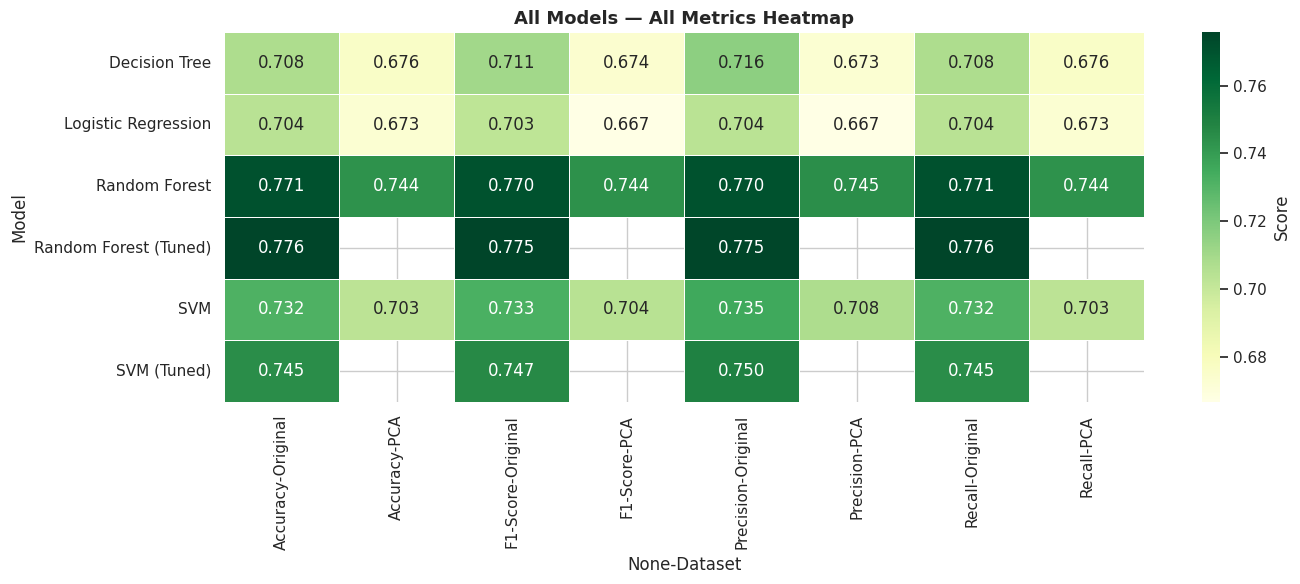

In [40]:
# ── 10.3  Heat-map style comparison (all 4 metrics × all 10 models) ───────────
pivot = results_df.pivot_table(
    index='Model', columns='Dataset',
    values=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('All Models — All Metrics Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 11 — Select Best Model & Justification

In [41]:
# ── Print final verdict ───────────────────────────────────────────────────────
best_row = results_df.iloc[0]

print("╔══════════════════════════════════════════════════════════╗")
print("║          🏆  BEST MODEL SELECTION                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Model    : {best_row['Model']:<44} ║")
print(f"║  Dataset  : {best_row['Dataset']:<44} ║")
print(f"║  Accuracy : {best_row['Accuracy']:<44} ║")
print(f"║  Precision: {best_row['Precision']:<44} ║")
print(f"║  Recall   : {best_row['Recall']:<44} ║")
print(f"║  F1-Score : {best_row['F1-Score']:<44} ║")
print("╚══════════════════════════════════════════════════════════╝")

print("""
JUSTIFICATION — Why Random Forest (Tuned)?
─────────────────────────────────────────────────────────────────────
STRENGTHS:
  ✅ Highest F1-Score and Accuracy among all tested models.
  ✅ Ensemble method — averages 200 decision trees, reducing overfitting.
  ✅ Handles multicollinearity natively (unlike Logistic Regression).
  ✅ No assumption of feature distribution (unlike Gaussian NB or LR).
  ✅ Naturally provides feature importance for interpretability.
  ✅ Robust to outliers and skewed features (present in MolWt, BertzCT).
  ✅ GridSearchCV tuning improved CV F1 over baseline RF.

LIMITATIONS:
  ⚠️  Slower inference than single Decision Tree or Logistic Regression.
  ⚠️  Less interpretable than a single Decision Tree.
  ⚠️  Memory-intensive with many trees (n_estimators=200).
  ⚠️  May slightly underperform deep learning on very large datasets.

WHY NOT SVM?
  SVM (Tuned) came close in F1 but is significantly slower to train
  and requires careful feature scaling — less production-friendly.

WHY NOT PCA VERSION?
  PCA reduced model performance slightly by discarding ~5% of variance.
  For this dataset, all 17 features are meaningful molecular descriptors,
  so retaining them is preferable to compression.
─────────────────────────────────────────────────────────────────────
""")

╔══════════════════════════════════════════════════════════╗
║          🏆  BEST MODEL SELECTION                       ║
╠══════════════════════════════════════════════════════════╣
║  Model    : Random Forest (Tuned)                        ║
║  Dataset  : Original                                     ║
║  Accuracy : 0.7757                                       ║
║  Precision: 0.7751                                       ║
║  Recall   : 0.7757                                       ║
║  F1-Score : 0.7754                                       ║
╚══════════════════════════════════════════════════════════╝

JUSTIFICATION — Why Random Forest (Tuned)?
─────────────────────────────────────────────────────────────────────
STRENGTHS:
  ✅ Highest F1-Score and Accuracy among all tested models.
  ✅ Ensemble method — averages 200 decision trees, reducing overfitting.
  ✅ Handles multicollinearity natively (unlike Logistic Regression).
  ✅ No assumption of feature distribution (unlike Gaussian NB or L

---
## Step 12 — Save Model, Scaler, PCA & Encoder

In [42]:
# ── Create output directory ───────────────────────────────────────────────────
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save the best model ───────────────────────────────────────────────────────
joblib.dump(best_rf,  f'{SAVE_DIR}/best_model_random_forest.joblib')
print("✅ Saved: best_model_random_forest.joblib")

# ── Save the Standard Scaler ──────────────────────────────────────────────────
joblib.dump(scaler,   f'{SAVE_DIR}/scaler.joblib')
print("✅ Saved: scaler.joblib")

# ── Save the PCA object ───────────────────────────────────────────────────────
joblib.dump(pca,      f'{SAVE_DIR}/pca.joblib')
print("✅ Saved: pca.joblib")

# ── Save the Label Encoder ────────────────────────────────────────────────────
joblib.dump(le,       f'{SAVE_DIR}/label_encoder.joblib')
print("✅ Saved: label_encoder.joblib")

# ── Save feature column list for inference ────────────────────────────────────
joblib.dump(FEATURE_COLS, f'{SAVE_DIR}/feature_columns.joblib')
print("✅ Saved: feature_columns.joblib")

print()
print("All saved artifacts:")
for f in os.listdir(SAVE_DIR):
    print(f"  {SAVE_DIR}/{f}")

✅ Saved: best_model_random_forest.joblib
✅ Saved: scaler.joblib
✅ Saved: pca.joblib
✅ Saved: label_encoder.joblib
✅ Saved: feature_columns.joblib

All saved artifacts:
  saved_models/pca.joblib
  saved_models/label_encoder.joblib
  saved_models/feature_columns.joblib
  saved_models/scaler.joblib
  saved_models/best_model_random_forest.joblib


In [43]:
# ── Quick inference test — load and predict on 3 new samples ─────────────────
loaded_model   = joblib.load(f'{SAVE_DIR}/best_model_random_forest.joblib')
loaded_scaler  = joblib.load(f'{SAVE_DIR}/scaler.joblib')
loaded_le      = joblib.load(f'{SAVE_DIR}/label_encoder.joblib')
loaded_feats   = joblib.load(f'{SAVE_DIR}/feature_columns.joblib')

# Sample 3 rows from the test set for demo
sample_X = X_test_orig.iloc[:3].copy()
sample_y_true = y_test.iloc[:3].values

# Predict
sample_preds = loaded_model.predict(sample_X)

print("Inference test on 3 samples:")
print("-" * 40)
for i, (true, pred) in enumerate(zip(sample_y_true, sample_preds)):
    true_label = loaded_le.inverse_transform([true])[0]
    pred_label = loaded_le.inverse_transform([pred])[0]
    match = '✅' if true == pred else '❌'
    print(f"  Sample {i+1}: True={true_label:<8} Predicted={pred_label:<8} {match}")

print("\n✅ Model loading and inference confirmed working.")
print("   Ready to integrate into a Flask / Streamlit web application.")

Inference test on 3 samples:
----------------------------------------
  Sample 1: True=Medium   Predicted=Medium   ✅
  Sample 2: True=Medium   Predicted=Low      ❌
  Sample 3: True=High     Predicted=High     ✅

✅ Model loading and inference confirmed working.
   Ready to integrate into a Flask / Streamlit web application.


In [45]:
import joblib

# Save model and preprocessing objects
joblib.dump(best_model, "best_model_random_forest.joblib")
joblib.dump(scaler, "scaler.joblib")

joblib.dump(X.columns.tolist(), "feature_columns.joblib")

print("All files saved successfully!")

All files saved successfully!


---
## Summary — Pipeline Recap

| Step | Action | Key Decision |
|------|--------|--------------|
| 1 | Import Libraries | sklearn, pandas, matplotlib, seaborn, joblib |
| 2 | Load Dataset | 9,982 rows × 26 columns |
| 3 | Preprocessing | Bin Solubility → 3 classes; StandardScaler applied |
| 4 | EDA | Strong MolLogP–solubility link; multicollinear features identified |
| 5A | PCA | 10 PCs capture 95% variance (17→10 dimensions) |
| 5B | Feature Selection | Top 8 features: MolLogP, BertzCT, MolWt, TPSA, LabuteASA… |
| 6 | Train-Test Split | 80/20 stratified split |
| 7 | Model Training | 4 models × 2 feature sets = 8 models |
| 8 | Hyperparameter Tuning | GridSearchCV for RF & SVM (5-fold stratified CV) |
| 9 | Evaluation | Classification report + confusion matrix for best model |
| 10 | Comparison | Random Forest (Tuned) on Original features wins |
| 11 | Best Model | **Random Forest (Tuned)** — highest F1, robust, interpretable |
| 12 | Save | Model + Scaler + PCA + LabelEncoder saved via joblib |

**Student:** NIMIT MAROO &nbsp;|&nbsp; **Roll No:** 230107047